In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, balanced_accuracy_score, classification_report
from sklearn.datasets import load_breast_cancer

import warnings
warnings.filterwarnings("ignore")

In [3]:
feature_space = ['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'mean compactness', 'mean concavity']

In [4]:
data = load_breast_cancer()

df_og = pd.DataFrame(data.data, columns=data.feature_names)
df_og['target'] = data.target

df_og.sample(1)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
202,23.29,26.67,158.9,1685.0,0.1141,0.2084,0.3523,0.162,0.22,0.06229,...,32.68,177.0,1986.0,0.1536,0.4167,0.7892,0.2733,0.3198,0.08762,0


In [5]:
df_og.value_counts('target')

target
1    357
0    212
Name: count, dtype: int64

In [6]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(df_og, test_size=0.3, random_state=0, stratify=df_og['target'])

X_test = test[feature_space]
y_test = test['target']

In [7]:
df_majority = train[train['target'] == 1]
df_minority = train[train['target'] == 0]

df_minority_undersampled = df_minority.sample(n=5, random_state=1)

df = pd.concat([df_majority, df_minority_undersampled])
df = df.sample(frac=1, random_state=1).reset_index(drop=True)

print('train df contains {} samples with target 0 and {} samples with target 1'.format(df['target'].value_counts()[0], df['target'].value_counts()[1]))

train df contains 5 samples with target 0 and 250 samples with target 1


In [8]:
import xgboost as xgb

X_train = df[feature_space]
y_train = df['target']

model = xgb.XGBClassifier(random_state=0)
model.fit(X_train, y_train)

y_preds = model.predict(X_test)

balanced_acc = balanced_accuracy_score(y_test, y_preds)
print("Balanced accuracy:", balanced_acc)

print(classification_report(y_test, y_preds, target_names=['Class 0','Class 1']))
print("Balanced accuracy:", balanced_accuracy_score(y_test, y_preds))


Balanced accuracy: 0.6703417056074766
              precision    recall  f1-score   support

     Class 0       0.92      0.36      0.52        64
     Class 1       0.72      0.98      0.83       107

    accuracy                           0.75       171
   macro avg       0.82      0.67      0.67       171
weighted avg       0.79      0.75      0.71       171

Balanced accuracy: 0.6703417056074766


In [9]:
df_base = df_minority_undersampled

In [10]:
from sdv.single_table import GaussianCopulaSynthesizer, CTGANSynthesizer
from sdv.metadata import Metadata
from imblearn.over_sampling import SMOTE, ADASYN, SVMSMOTE, KMeansSMOTE, RandomOverSampler

In [11]:
def generate_minority_df(df_majority, df_minority, ratio: int, synthesizer: str):
    n_majority = len(df_majority)
    desired_minority_total = n_majority // ratio
    n_to_generate = max(desired_minority_total - len(df_minority), 0)
    df_synth = pd.DataFrame()
    
    if n_to_generate == 0:
        return pd.concat([df_majority, df_minority]).reset_index(drop=True)
    
    if synthesizer == 'gaussian':
    
        metadata = Metadata.detect_from_dataframe(data=df_minority)
        gc = GaussianCopulaSynthesizer(metadata)
        gc.fit(df_minority)
        df_synth = gc.sample(n_to_generate)

    elif synthesizer == 'ctgan':

        metadata = Metadata.detect_from_dataframe(data=df_minority)
        ctgan = CTGANSynthesizer(metadata, cuda=False)
        ctgan.fit(df_minority)
        df_synth = ctgan.sample(n_to_generate)

    elif synthesizer == 'smote':

        smote = SMOTE(sampling_strategy=1/ratio, random_state=0, k_neighbors=4)
        tmp = pd.concat([df_majority, df_minority]).reset_index(drop=True)
        X_tmp = tmp[feature_space]
        y_tmp = tmp['target']
        X_train_sm, y_train_sm = smote.fit_resample(X_tmp, y_tmp)
        tmp = pd.concat([X_train_sm, y_train_sm], axis=1).reset_index(drop=True)
        
        return tmp[feature_space], tmp['target']
    
    elif synthesizer == 'adasyn':

        adasyn = ADASYN(sampling_strategy=1/ratio, random_state=0, n_neighbors=4)
        tmp = pd.concat([df_majority, df_minority]).reset_index(drop=True)
        X_tmp = tmp[feature_space]
        y_tmp = tmp['target']
        X_train_sm, y_train_sm = adasyn.fit_resample(X_tmp, y_tmp)
        tmp = pd.concat([X_train_sm, y_train_sm], axis=1).reset_index(drop=True)
        
        return tmp[feature_space], tmp['target']
    
    elif synthesizer == 'svm_smote':

        svm_smote = SVMSMOTE(sampling_strategy=1/ratio, random_state=0, k_neighbors=4)
        tmp = pd.concat([df_majority, df_minority]).reset_index(drop=True)
        X_tmp = tmp[feature_space]
        y_tmp = tmp['target']
        X_train_sm, y_train_sm = svm_smote.fit_resample(X_tmp, y_tmp)
        tmp = pd.concat([X_train_sm, y_train_sm], axis=1).reset_index(drop=True)
        
        return tmp[feature_space], tmp['target']
    
    elif synthesizer == 'kmeans_smote':

        kmeans_smote = KMeansSMOTE(sampling_strategy=1/ratio, random_state=0, k_neighbors=4)
        tmp = pd.concat([df_majority, df_minority]).reset_index(drop=True)
        X_tmp = tmp[feature_space]
        y_tmp = tmp['target']
        X_train_sm, y_train_sm = kmeans_smote.fit_resample(X_tmp, y_tmp)
        tmp = pd.concat([X_train_sm, y_train_sm], axis=1).reset_index(drop=True)
        
        return tmp[feature_space], tmp['target']
    
    elif synthesizer == 'random_oversample':

        tmp = pd.concat([df_majority, df_minority]).reset_index(drop=True)
        X_tmp = tmp[feature_space]
        y_tmp = tmp['target']

        ros = RandomOverSampler(
            sampling_strategy={0: desired_minority_total},
            random_state=0
        )

        X_res, y_res = ros.fit_resample(X_tmp, y_tmp)
        tmp_res = pd.concat([X_res, y_res], axis=1).reset_index(drop=True)

        return tmp_res[feature_space], tmp_res['target']

    df_minority_expanded = pd.concat([df_minority, df_synth]).reset_index(drop=True)
    df_combined = pd.concat([df_majority, df_minority_expanded]).reset_index(drop=True)
    
    return df_combined[feature_space], df_combined['target']

In [12]:
X_dfGaussian25, y_dfGaussian25 = generate_minority_df(df_majority, df_minority_undersampled, ratio=25, synthesizer='gaussian')
X_dfGaussian10, y_dfGaussian10 = generate_minority_df(df_majority, df_minority_undersampled, ratio=10, synthesizer='gaussian')
X_dfGaussian5, y_dfGaussian5 = generate_minority_df(df_majority, df_minority_undersampled, ratio=5, synthesizer='gaussian')  
X_dfGaussian2, y_dfGaussian2 = generate_minority_df(df_majority, df_minority_undersampled, ratio=2, synthesizer='gaussian')
X_dfGaussian1, y_dfGaussian1 = generate_minority_df(df_majority, df_minority_undersampled, ratio=1, synthesizer='gaussian')

In [13]:
len(X_dfGaussian25)

260

In [14]:
X_dfCTGAN25, y_dfCTGAN25 = generate_minority_df(df_majority, df_minority_undersampled, ratio=25, synthesizer='ctgan')
X_dfCTGAN10, y_dfCTGAN10 = generate_minority_df(df_majority, df_minority_undersampled, ratio=10, synthesizer='ctgan')
X_dfCTGAN5, y_dfCTGAN5 = generate_minority_df(df_majority, df_minority_undersampled, ratio=5, synthesizer='ctgan')
X_dfCTGAN2, y_dfCTGAN2 = generate_minority_df(df_majority, df_minority_undersampled, ratio=2, synthesizer='ctgan')
X_dfCTGAN1, y_dfCTGAN1 = generate_minority_df(df_majority, df_minority_undersampled, ratio=1, synthesizer='ctgan')

In [15]:
X_dfSMOTE25, y_dfSMOTE25 = generate_minority_df(df_majority, df_minority_undersampled, ratio=25, synthesizer='smote')
X_dfSMOTE10, y_dfSMOTE10 = generate_minority_df(df_majority, df_minority_undersampled, ratio=10, synthesizer='smote')
X_dfSMOTE5, y_dfSMOTE5 = generate_minority_df(df_majority, df_minority_undersampled, ratio=5, synthesizer='smote')  
X_dfSMOTE2, y_dfSMOTE2 = generate_minority_df(df_majority, df_minority_undersampled, ratio=2, synthesizer='smote')  
X_dfSMOTE1, y_dfSMOTE1 = generate_minority_df(df_majority, df_minority_undersampled, ratio=1, synthesizer='smote')     

In [16]:
X_dfADASYN25, y_dfADASYN25 = generate_minority_df(df_majority, df_minority_undersampled, ratio=25, synthesizer='adasyn')
X_dfADASYN10, y_dfADASYN10 = generate_minority_df(df_majority, df_minority_undersampled, ratio=10, synthesizer='adasyn')
X_dfADASYN5, y_dfADASYN5 = generate_minority_df(df_majority, df_minority_undersampled, ratio=5, synthesizer='adasyn')
X_dfADASYN2, y_dfADASYN2 = generate_minority_df(df_majority, df_minority_undersampled, ratio=2, synthesizer='adasyn')
X_dfADASYN1, y_dfADASYN1 = generate_minority_df(df_majority, df_minority_undersampled, ratio=1, synthesizer='adasyn')

In [17]:
X_dfRandom25, y_dfRandom25 = generate_minority_df(df_majority, df_minority_undersampled, ratio=25, synthesizer='random_oversample')
X_dfRandom10, y_dfRandom10 = generate_minority_df(df_majority, df_minority_undersampled, ratio=10, synthesizer='random_oversample')
X_dfRandom5, y_dfRandom5 = generate_minority_df(df_majority, df_minority_undersampled, ratio=5, synthesizer='random_oversample')
X_dfRandom2, y_dfRandom2 = generate_minority_df(df_majority, df_minority_undersampled, ratio=2, synthesizer='random_oversample')
X_dfRandom1, y_dfRandom1 = generate_minority_df(df_majority, df_minority_undersampled, ratio=1, synthesizer='random_oversample')

In [18]:
print(y_dfGaussian2.value_counts('target'), y_dfCTGAN2.value_counts('target'), y_dfSMOTE2.value_counts('target')
, y_dfADASYN2.value_counts('target'), y_dfRandom2.value_counts('target'))
print(len(y_dfGaussian2), len(y_dfCTGAN2), len(y_dfSMOTE2), len(y_dfADASYN2), len(y_dfRandom2))

target
1    0.666667
0    0.333333
Name: proportion, dtype: float64 target
1    0.666667
0    0.333333
Name: proportion, dtype: float64 target
1    0.666667
0    0.333333
Name: proportion, dtype: float64 target
1    0.664894
0    0.335106
Name: proportion, dtype: float64 target
1    0.666667
0    0.333333
Name: proportion, dtype: float64
375 375 375 376 375


In [19]:
import time
import xgboost as xgb
import optuna
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import balanced_accuracy_score, recall_score

def optuna_search(clf, X, y, n_trials=100):
    
    start_time = time.time()  # start timer before the whole process

    def objective(trial):
        param = {
            'max_depth': trial.suggest_int('max_depth', 3, 10),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
            'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
            'subsample': trial.suggest_float('subsample', 0.5, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
            'gamma': trial.suggest_float('gamma', 0, 5),
            'use_label_encoder': False,
            'eval_metric': 'logloss'
        }

        model = xgb.XGBClassifier(**param, random_state=0)
        score = cross_val_score(model, X, y, cv=5, n_jobs=-1).mean()
        return score

    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False, n_jobs=-1)

    best_params = study.best_params
    final_model = xgb.XGBClassifier(**best_params, use_label_encoder=False, eval_metric='logloss', random_state=0)
    final_model.fit(X, y)  # fit final model

    end_time = time.time()  # stop timer after final fit
    runtime = end_time - start_time

    bal = balanced_accuracy_score(y_test, final_model.predict(X_test))
    rec = recall_score(y_test, final_model.predict(X_test), pos_label=0)

    return bal, rec, runtime

In [20]:
def run_optuna_searches(dataset_list):
    results = []
    for label, size, X, y in dataset_list:
        clf = xgb.XGBClassifier()
        result = optuna_search(clf, X, y)
        results.append((label, size, result))
    return results

In [21]:
dataset_list_gaussian = [
    ('Gaussian', 25, X_dfGaussian25, y_dfGaussian25),
    ('Gaussian', 10, X_dfGaussian10, y_dfGaussian10),
    ('Gaussian', 5, X_dfGaussian5, y_dfGaussian5),
    ('Gaussian', 2, X_dfGaussian2, y_dfGaussian2),
    ('Gaussian', 1, X_dfGaussian1, y_dfGaussian1)
]

results_optuna_gaussian = run_optuna_searches(dataset_list_gaussian)

print(results_optuna_gaussian)

[I 2026-03-26 22:16:06,960] A new study created in memory with name: no-name-95ed12cd-f111-46e3-8ad9-2c797d55969d
[I 2026-03-26 22:16:20,299] Trial 3 finished with value: 0.9846153846153847 and parameters: {'max_depth': 3, 'learning_rate': 0.05893910841557026, 'n_estimators': 102, 'subsample': 0.6678575440514987, 'colsample_bytree': 0.6532345817095209, 'min_child_weight': 1, 'gamma': 0.6694932350924693}. Best is trial 3 with value: 0.9846153846153847.
[I 2026-03-26 22:16:20,449] Trial 2 finished with value: 0.9615384615384615 and parameters: {'max_depth': 4, 'learning_rate': 0.09760591440548655, 'n_estimators': 836, 'subsample': 0.6940954546687802, 'colsample_bytree': 0.727127328642698, 'min_child_weight': 7, 'gamma': 4.571165479030662}. Best is trial 3 with value: 0.9846153846153847.
[I 2026-03-26 22:16:20,483] Trial 1 finished with value: 0.9615384615384615 and parameters: {'max_depth': 7, 'learning_rate': 0.07390880541135234, 'n_estimators': 287, 'subsample': 0.7327248085648083, 'co

[('Gaussian', 25, (0.6469042056074766, 0.3125, 22.64021873474121)), ('Gaussian', 10, (0.8109667056074766, 0.640625, 9.13267469406128)), ('Gaussian', 5, (0.8172459112149533, 0.671875, 11.310051441192627)), ('Gaussian', 2, (0.8172459112149533, 0.671875, 9.626179933547974)), ('Gaussian', 1, (0.8125730140186915, 0.671875, 11.501293659210205))]


In [22]:
dataset_list_ctgan = [
    ('CTGAN', 25, X_dfCTGAN25, y_dfCTGAN25),
    ('CTGAN', 10, X_dfCTGAN10, y_dfCTGAN10),
    ('CTGAN', 5, X_dfCTGAN5, y_dfCTGAN5),
    ('CTGAN', 2, X_dfCTGAN2, y_dfCTGAN2),
    ('CTGAN', 1, X_dfCTGAN1, y_dfCTGAN1)
]

results_optuna_ctgan = run_optuna_searches(dataset_list_ctgan)

print(results_optuna_ctgan)

[I 2026-03-26 22:17:11,389] A new study created in memory with name: no-name-95a4a2cd-e9c5-4859-a78e-6a50aab8d9bd
[I 2026-03-26 22:17:11,720] Trial 0 finished with value: 0.9615384615384615 and parameters: {'max_depth': 3, 'learning_rate': 0.06640367130485732, 'n_estimators': 987, 'subsample': 0.9314587446332392, 'colsample_bytree': 0.5065975453577287, 'min_child_weight': 9, 'gamma': 3.0711646016198104}. Best is trial 0 with value: 0.9615384615384615.
[I 2026-03-26 22:17:11,824] Trial 2 finished with value: 0.9615384615384615 and parameters: {'max_depth': 3, 'learning_rate': 0.0786678270391297, 'n_estimators': 717, 'subsample': 0.8846639983314337, 'colsample_bytree': 0.5194307545726764, 'min_child_weight': 7, 'gamma': 0.06918879746735496}. Best is trial 0 with value: 0.9615384615384615.
[I 2026-03-26 22:17:11,896] Trial 1 finished with value: 0.9615384615384615 and parameters: {'max_depth': 10, 'learning_rate': 0.025799712093349754, 'n_estimators': 487, 'subsample': 0.9627659537956381,

[('CTGAN', 25, (0.7265625, 0.453125, 8.278943300247192)), ('CTGAN', 10, (0.8109667056074766, 0.640625, 12.248447179794312)), ('CTGAN', 5, (0.821918808411215, 0.671875, 11.009872436523438)), ('CTGAN', 2, (0.8094334112149533, 0.65625, 11.754152059555054)), ('CTGAN', 1, (0.8172459112149533, 0.671875, 13.75704836845398))]


In [23]:
dataset_list_smote = [
    ('SMOTE', 25, X_dfSMOTE25, y_dfSMOTE25),
    ('SMOTE', 10, X_dfSMOTE10, y_dfSMOTE10),
    ('SMOTE', 5, X_dfSMOTE5, y_dfSMOTE5),
    ('SMOTE', 2, X_dfSMOTE2, y_dfSMOTE2),
    ('SMOTE', 1, X_dfSMOTE1, y_dfSMOTE1)
]

results_optuna_smote = run_optuna_searches(dataset_list_smote)

print(results_optuna_smote)

[I 2026-03-26 22:18:08,493] A new study created in memory with name: no-name-26d10a91-2e9e-460a-99e2-7de3427ba010
[I 2026-03-26 22:18:08,697] Trial 0 finished with value: 0.9615384615384615 and parameters: {'max_depth': 9, 'learning_rate': 0.04624280428201701, 'n_estimators': 717, 'subsample': 0.5003275546928947, 'colsample_bytree': 0.7209482821417554, 'min_child_weight': 6, 'gamma': 2.6292391608643357}. Best is trial 0 with value: 0.9615384615384615.
[I 2026-03-26 22:18:08,827] Trial 1 finished with value: 0.9615384615384615 and parameters: {'max_depth': 8, 'learning_rate': 0.03438130248950716, 'n_estimators': 808, 'subsample': 0.5601700389112557, 'colsample_bytree': 0.9776190809663339, 'min_child_weight': 5, 'gamma': 3.9714304822136794}. Best is trial 0 with value: 0.9615384615384615.
[I 2026-03-26 22:18:08,942] Trial 3 finished with value: 0.9615384615384615 and parameters: {'max_depth': 5, 'learning_rate': 0.05533768653993411, 'n_estimators': 855, 'subsample': 0.9753661361572661, '

[('SMOTE', 25, (0.8187792056074766, 0.65625, 7.45277738571167)), ('SMOTE', 10, (0.8265917056074766, 0.671875, 11.674072742462158)), ('SMOTE', 5, (0.821918808411215, 0.671875, 16.025314807891846)), ('SMOTE', 2, (0.821918808411215, 0.671875, 9.997207403182983)), ('SMOTE', 1, (0.8281980140186915, 0.703125, 10.995960235595703))]


In [24]:
dataset_list_adasyn = [
    ('ADASYN', 25, X_dfADASYN25, y_dfADASYN25),
    ('ADASYN', 10, X_dfADASYN10, y_dfADASYN10),
    ('ADASYN', 5, X_dfADASYN5, y_dfADASYN5),
    ('ADASYN', 2, X_dfADASYN2, y_dfADASYN2),
    ('ADASYN', 1, X_dfADASYN1, y_dfADASYN1)
]

results_optuna_adasyn = run_optuna_searches(dataset_list_adasyn)

print(results_optuna_adasyn)

[I 2026-03-26 22:19:04,690] A new study created in memory with name: no-name-aad8ee68-f253-4edb-9be5-f4bdd1f8a938
[I 2026-03-26 22:19:04,921] Trial 1 finished with value: 0.976923076923077 and parameters: {'max_depth': 4, 'learning_rate': 0.026247628999070426, 'n_estimators': 771, 'subsample': 0.7527640517377969, 'colsample_bytree': 0.6688229861885466, 'min_child_weight': 2, 'gamma': 2.480965779771745}. Best is trial 1 with value: 0.976923076923077.
[I 2026-03-26 22:19:04,978] Trial 2 finished with value: 0.9615384615384615 and parameters: {'max_depth': 8, 'learning_rate': 0.06154462618661811, 'n_estimators': 406, 'subsample': 0.6091627669113008, 'colsample_bytree': 0.8678463821727751, 'min_child_weight': 9, 'gamma': 0.8328380986538525}. Best is trial 1 with value: 0.976923076923077.
[I 2026-03-26 22:19:04,998] Trial 0 finished with value: 0.9615384615384615 and parameters: {'max_depth': 6, 'learning_rate': 0.06117851998315325, 'n_estimators': 111, 'subsample': 0.7281230919967071, 'col

[('ADASYN', 25, (0.6703417056074766, 0.359375, 8.99341630935669)), ('ADASYN', 10, (0.814106308411215, 0.65625, 11.982573509216309)), ('ADASYN', 5, (0.821918808411215, 0.671875, 16.88304615020752)), ('ADASYN', 2, (0.8172459112149533, 0.671875, 13.225239753723145)), ('ADASYN', 1, (0.8328709112149533, 0.703125, 9.008027076721191))]


In [25]:
dataset_list_random = [
    ('Random', 25, X_dfRandom25, y_dfRandom25),
    ('Random', 10, X_dfRandom10, y_dfRandom10),
    ('Random', 5, X_dfRandom5, y_dfRandom5),
    ('Random', 2, X_dfRandom2, y_dfRandom2),
    ('Random', 1, X_dfRandom1, y_dfRandom1)
]

results_optuna_random = run_optuna_searches(dataset_list_random)

print(results_optuna_random)

[I 2026-03-26 22:20:04,834] A new study created in memory with name: no-name-dce6a9d8-f42d-4998-9039-31762f8ba3eb
[I 2026-03-26 22:20:04,954] Trial 0 finished with value: 0.9615384615384615 and parameters: {'max_depth': 3, 'learning_rate': 0.02809702298070775, 'n_estimators': 159, 'subsample': 0.8182617320848378, 'colsample_bytree': 0.6277660356921754, 'min_child_weight': 6, 'gamma': 0.3547715307715249}. Best is trial 0 with value: 0.9615384615384615.
[I 2026-03-26 22:20:05,131] Trial 2 finished with value: 0.973076923076923 and parameters: {'max_depth': 4, 'learning_rate': 0.030652092896504148, 'n_estimators': 931, 'subsample': 0.8010890654492097, 'colsample_bytree': 0.540429900450331, 'min_child_weight': 2, 'gamma': 4.499017352726008}. Best is trial 2 with value: 0.973076923076923.
[I 2026-03-26 22:20:05,206] Trial 1 finished with value: 0.9846153846153847 and parameters: {'max_depth': 5, 'learning_rate': 0.06051962508981792, 'n_estimators': 463, 'subsample': 0.8326388760901169, 'col

[('Random', 25, (0.7406542056074766, 0.5, 9.768624067306519)), ('Random', 10, (0.8187792056074766, 0.65625, 13.265704154968262)), ('Random', 5, (0.8172459112149533, 0.671875, 13.969652891159058)), ('Random', 2, (0.8109667056074766, 0.640625, 11.584624290466309)), ('Random', 1, (0.798481308411215, 0.625, 14.824957370758057))]


In [26]:
print(results_optuna_gaussian)
print(results_optuna_ctgan)
print(results_optuna_smote)
print(results_optuna_adasyn)
print(results_optuna_random)

[('Gaussian', 25, (0.6469042056074766, 0.3125, 22.64021873474121)), ('Gaussian', 10, (0.8109667056074766, 0.640625, 9.13267469406128)), ('Gaussian', 5, (0.8172459112149533, 0.671875, 11.310051441192627)), ('Gaussian', 2, (0.8172459112149533, 0.671875, 9.626179933547974)), ('Gaussian', 1, (0.8125730140186915, 0.671875, 11.501293659210205))]
[('CTGAN', 25, (0.7265625, 0.453125, 8.278943300247192)), ('CTGAN', 10, (0.8109667056074766, 0.640625, 12.248447179794312)), ('CTGAN', 5, (0.821918808411215, 0.671875, 11.009872436523438)), ('CTGAN', 2, (0.8094334112149533, 0.65625, 11.754152059555054)), ('CTGAN', 1, (0.8172459112149533, 0.671875, 13.75704836845398))]
[('SMOTE', 25, (0.8187792056074766, 0.65625, 7.45277738571167)), ('SMOTE', 10, (0.8265917056074766, 0.671875, 11.674072742462158)), ('SMOTE', 5, (0.821918808411215, 0.671875, 16.025314807891846)), ('SMOTE', 2, (0.821918808411215, 0.671875, 9.997207403182983)), ('SMOTE', 1, (0.8281980140186915, 0.703125, 10.995960235595703))]
[('ADASYN',

In [27]:
def extract_values(input_lists, n):

    data = {}
    for method_list in input_lists:
        if not method_list:
            continue
        method_name = method_list[0][0]  # The first element is the method name
        data[method_name] = [tup[2][n] for tup in method_list]  # Extract the middle value
    return data

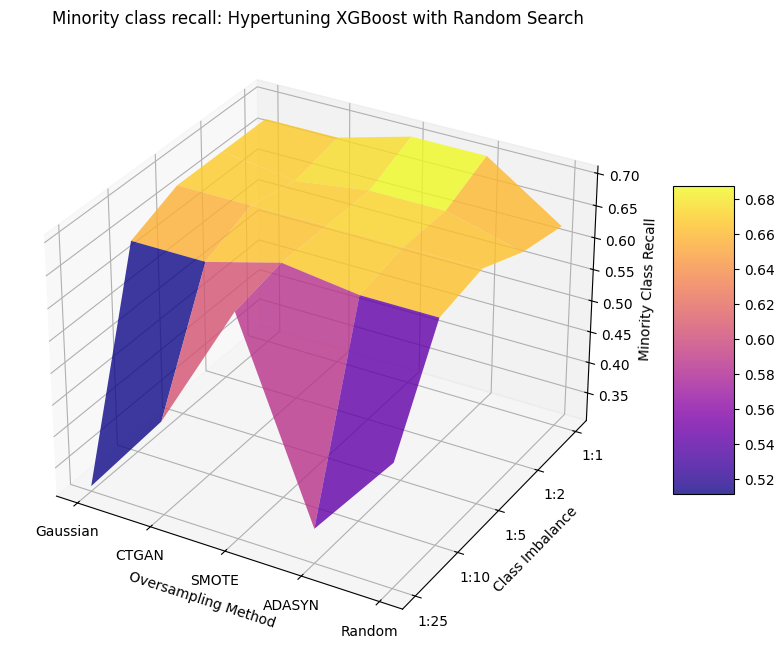

In [28]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D

# 1. Organize the data
data = extract_values([
    results_optuna_gaussian,
    results_optuna_ctgan,
    results_optuna_smote,
    results_optuna_adasyn,
    results_optuna_random
], n=1)

labels = list(data.keys())
sizes = [25, 10, 5, 2, 1]

# 2. Create numerical mappings for the X and Y axes
x_indices = np.arange(len(labels))
y_indices = np.arange(len(sizes))
y_labels = [f'1:{size}' for size in sizes]
X, Y = np.meshgrid(x_indices, y_indices)

# 3. Extract Z values (Recall) into a grid
# We transpose or align based on the meshgrid shape
Z = np.array([data[label] for label in labels]).T

# 4. Plotting
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot the surface
surf = ax.plot_surface(X, Y, Z, cmap='plasma', edgecolor='none', alpha=0.8)

# Customize axes
ax.set_xticks(x_indices)
ax.set_xticklabels(labels)
ax.set_yticks(y_indices)
ax.set_yticklabels(y_labels)

ax.set_xlabel('Oversampling Method')
ax.set_ylabel('Class Imbalance')
ax.set_zlabel('Minority Class Recall')
ax.set_title('Minority class recall: Hypertuning XGBoost with Random Search')

# Add a color bar for reference
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5)

plt.show()

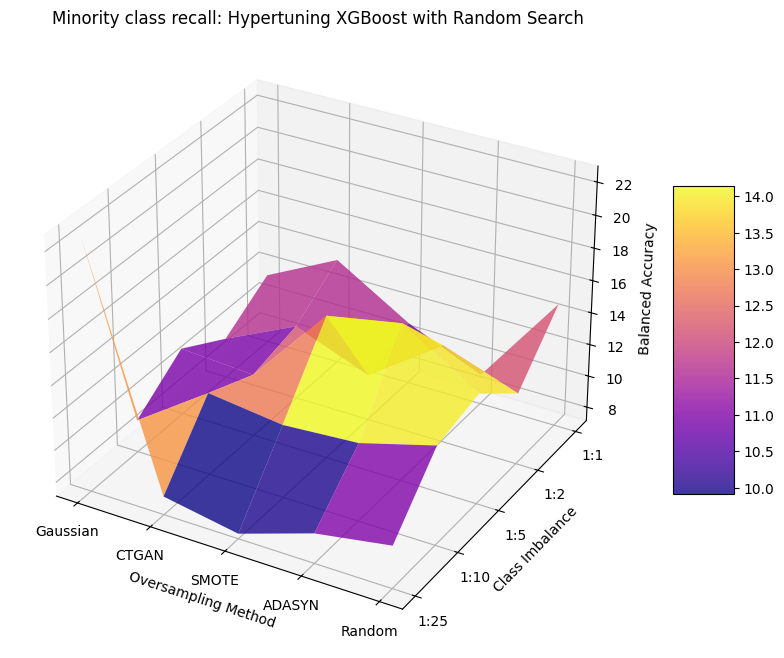

In [29]:
# 1. Organize the data
data = extract_values([
    results_optuna_gaussian,
    results_optuna_ctgan,
    results_optuna_smote,
    results_optuna_adasyn,
    results_optuna_random
], n=2)

labels = list(data.keys())
sizes = [25, 10, 5, 2, 1]

# 2. Create numerical mappings for the X and Y axes
x_indices = np.arange(len(labels))
y_indices = np.arange(len(sizes))
y_labels = [f'1:{size}' for size in sizes]
X, Y = np.meshgrid(x_indices, y_indices)

# 3. Extract Z values (Recall) into a grid
# We transpose or align based on the meshgrid shape
Z = np.array([data[label] for label in labels]).T

# 4. Plotting
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot the surface
surf = ax.plot_surface(X, Y, Z, cmap='plasma', edgecolor='none', alpha=0.8)

# Customize axes
ax.set_xticks(x_indices)
ax.set_xticklabels(labels)
ax.set_yticks(y_indices)
ax.set_yticklabels(y_labels)

ax.set_xlabel('Oversampling Method')
ax.set_ylabel('Class Imbalance')
ax.set_zlabel('Balanced Accuracy')
ax.set_title('Minority class recall: Hypertuning XGBoost with Random Search')

# Add a color bar for reference
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5)

plt.show()

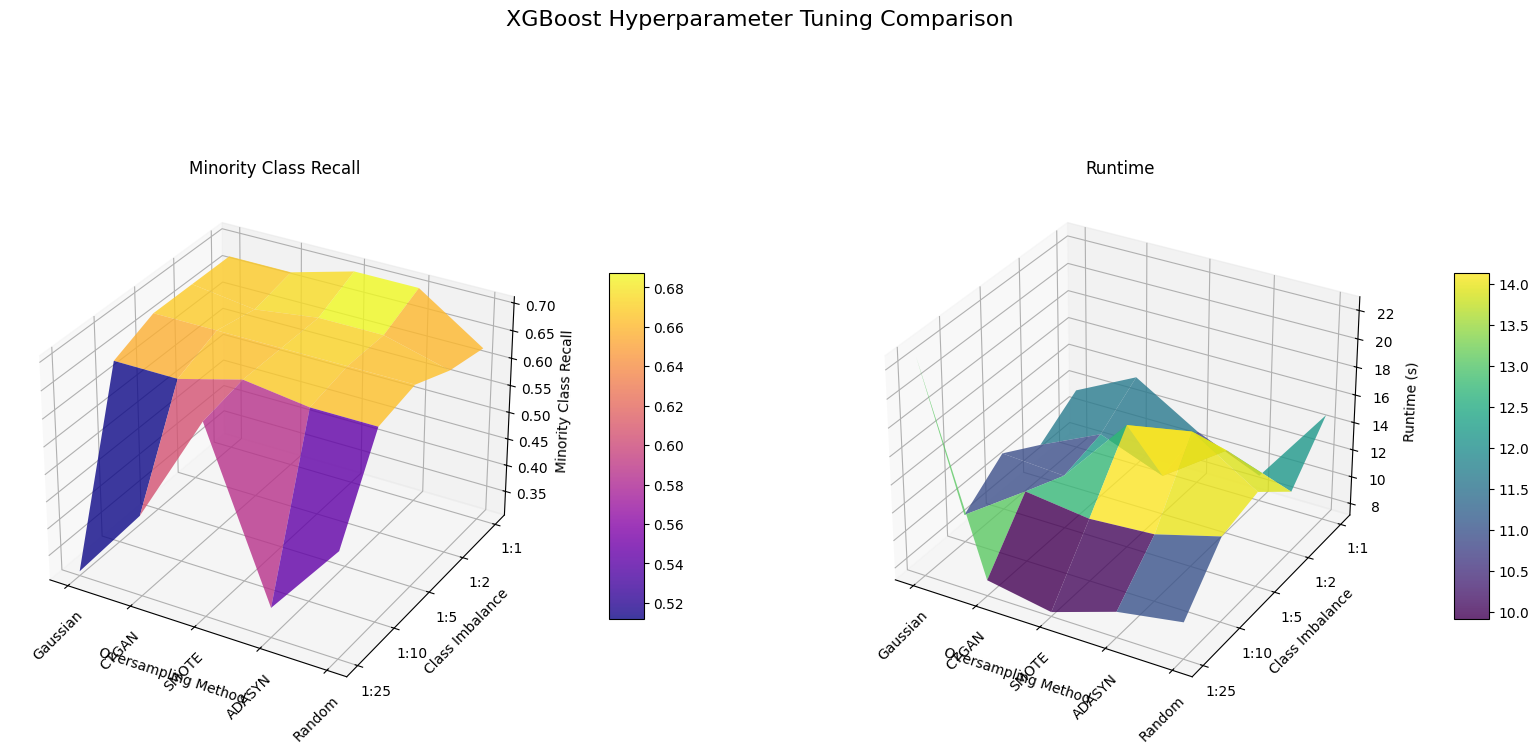

In [30]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D

# 1. Organize the data for both metrics
# Data for Recall (n=1)
data_recall = extract_values([
    results_optuna_gaussian,
    results_optuna_ctgan,
    results_optuna_smote,
    results_optuna_adasyn,
    results_optuna_random
], n=1)

# Data for Balanced Accuracy (n=2)
data_acc = extract_values([
    results_optuna_gaussian,
    results_optuna_ctgan,
    results_optuna_smote,
    results_optuna_adasyn,
    results_optuna_random
], n=2)

labels = list(data_recall.keys())
sizes = [25, 10, 5, 2, 1]

# 2. Create numerical mappings (shared by both)
x_indices = np.arange(len(labels))
y_indices = np.arange(len(sizes))
y_labels = [f'1:{size}' for size in sizes]
X, Y = np.meshgrid(x_indices, y_indices)

# 3. Extract Z values
Z1 = np.array([data_recall[label] for label in labels]).T
Z2 = np.array([data_acc[label] for label in labels]).T

# 4. Plotting in one figure with two subplots
fig = plt.figure(figsize=(20, 9)) # Increased width for two 3D plots

# --- Subplot 1: Minority Class Recall ---
ax1 = fig.add_subplot(121, projection='3d')
surf1 = ax1.plot_surface(X, Y, Z1, cmap='plasma', edgecolor='none', alpha=0.8)

ax1.set_xticks(x_indices)
ax1.set_xticklabels(labels, rotation=45)
ax1.set_yticks(y_indices)
ax1.set_yticklabels(y_labels)

ax1.set_xlabel('Oversampling Method')
ax1.set_ylabel('Class Imbalance')
ax1.set_zlabel('Minority Class Recall')
ax1.set_title('Minority Class Recall')
fig.colorbar(surf1, ax=ax1, shrink=0.5, aspect=10, pad=0.1)

# --- Subplot 2: Balanced Accuracy ---
ax2 = fig.add_subplot(122, projection='3d')
surf2 = ax2.plot_surface(X, Y, Z2, cmap='viridis', edgecolor='none', alpha=0.8)

ax2.set_xticks(x_indices)
ax2.set_xticklabels(labels, rotation=45)
ax2.set_yticks(y_indices)
ax2.set_yticklabels(y_labels)

ax2.set_xlabel('Oversampling Method')
ax2.set_ylabel('Class Imbalance')
ax2.set_zlabel('Runtime (s)')
ax2.set_title('Runtime')
fig.colorbar(surf2, ax=ax2, shrink=0.5, aspect=10, pad=0.1)

plt.suptitle('XGBoost Hyperparameter Tuning Comparison', fontsize=16)
plt.tight_layout()
plt.show()

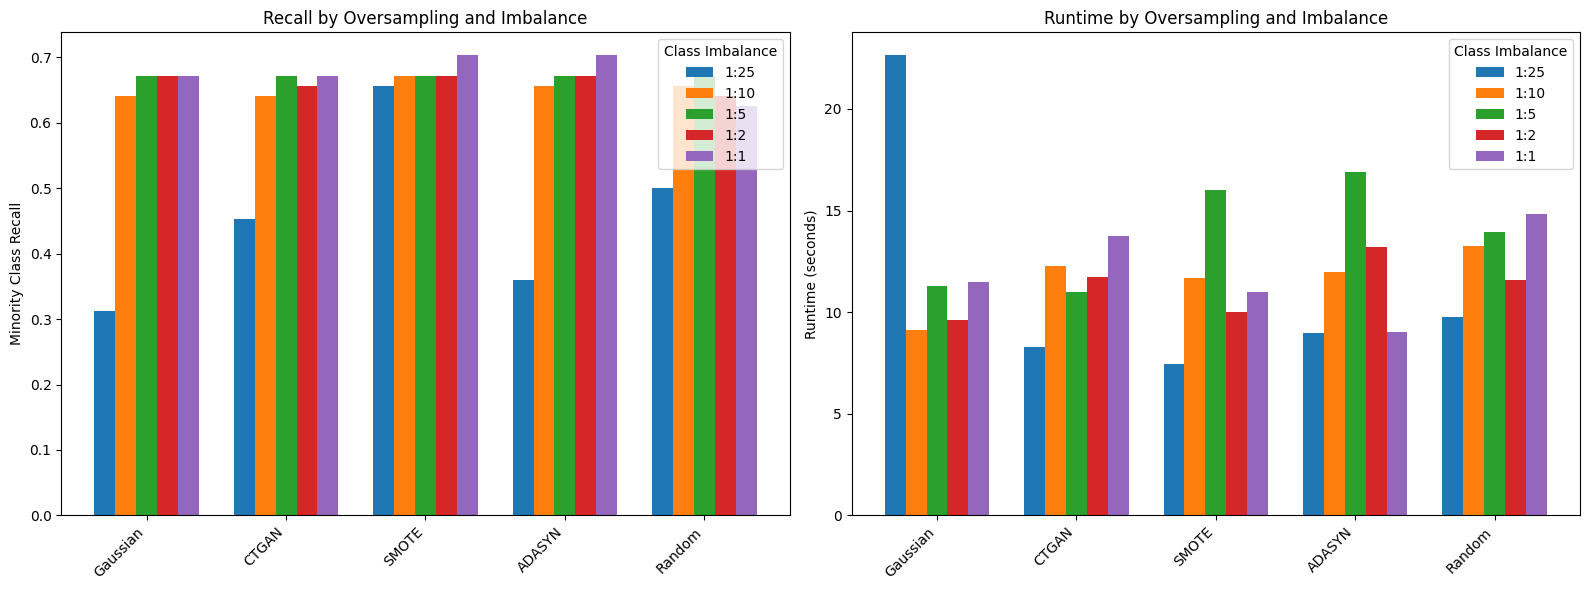

In [31]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), sharex=True)

x = np.arange(len(labels))  # oversampling methods
width = 0.15

for i, size in enumerate(sizes):
    recall_vals = Z1[i]
    runtime_vals = Z2[i]
    ax1.bar(x + i*width, recall_vals, width, label=f'1:{size}')
    ax2.bar(x + i*width, runtime_vals, width, label=f'1:{size}')

ax1.set_xticks(x + width * (len(sizes)-1) / 2)
ax1.set_xticklabels(labels, rotation=45, ha='right')
ax1.set_ylabel('Minority Class Recall')
ax1.set_title('Recall by Oversampling and Imbalance')
ax1.legend(title='Class Imbalance')

ax2.set_xticks(x + width * (len(sizes)-1) / 2)
ax2.set_xticklabels(labels, rotation=45, ha='right')
ax2.set_ylabel('Runtime (seconds)')
ax2.set_title('Runtime by Oversampling and Imbalance')
ax2.legend(title='Class Imbalance')

plt.tight_layout()
plt.show()